In [ ]:
##This project predicts telecom customer churn using Logistic Regression.
##Dataset: 7043 customers, 31 features.
##Accuracy: 82% on test data.
##Key churn drivers: contract type, monthly charges, tenure.


In [ ]:
# Step 1: Import Libraries
# Step 2: Load Data
# Step 3: Preprocessing
# Step 4: Train/Test Split
# Step 5: Model Training
# Step 6: Evaluation
# Step 7: Insights

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

In [ ]:
# Set global plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [ ]:
##load file
import pandas as pd

df = pd.read_excel("Telco-Customer-Churn.csv.xlsx")
print(df.shape)
df.head()


(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Total Charges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
#Remove repeated outputs
df['Partner'] = df['Partner'].map({'Yes':1, 'No':0})
df['Dependents'] = df['Dependents'].map({'Yes':1, 'No':0})
df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes':1, 'No':0})
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'] = df['Total Charges'].fillna(df['Total Charges'].median())

df = df.drop('customerID', axis=1)
df = pd.get_dummies(df, drop_first=True)

print(df.shape)
print(df.isnull().sum().sum())

(7043, 31)
0


In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8204400283889283

Confusion Matrix:
 [[934 102]
 [151 222]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



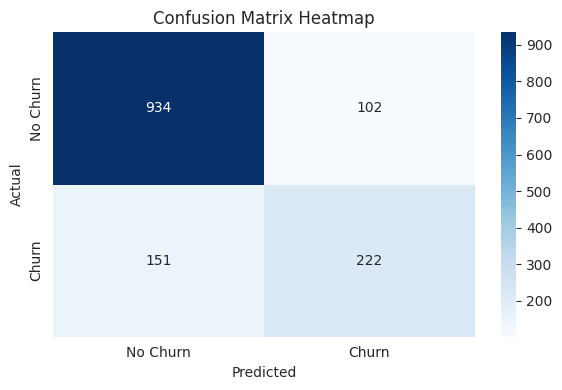

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.tight_layout()   # <-- polish line
plt.show()

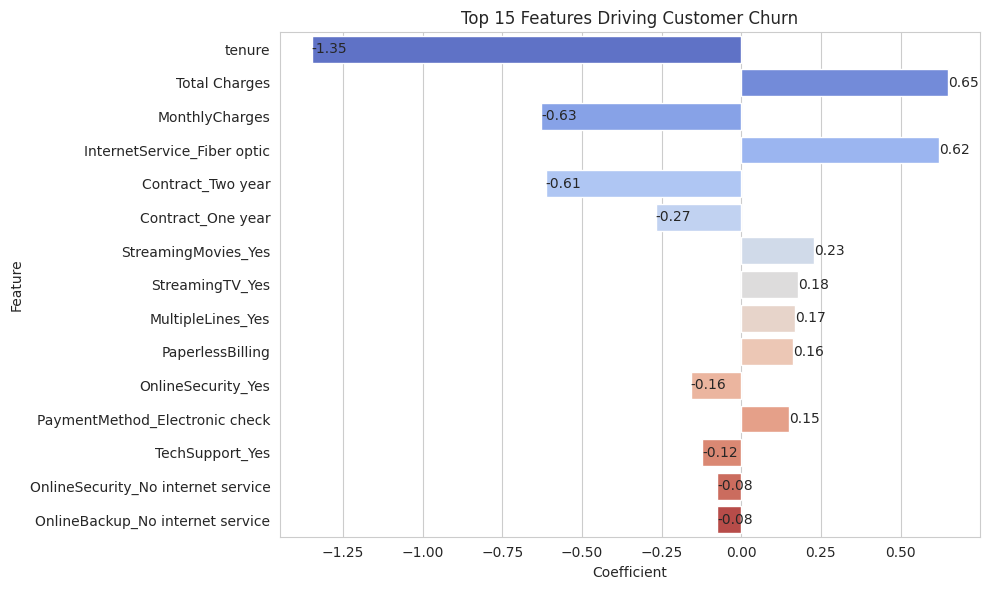

In [ ]:
# Feature Importance Bar Chart (Final Polished Version with Labels)
coefficients = model.coef_[0]
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients
})
importance_df['AbsCoef'] = importance_df['Coefficient'].abs()
importance_df = importance_df.sort_values(by='AbsCoef', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Feature',
            data=importance_df.head(15),
            hue='Feature',        # fixes FutureWarning
            dodge=False,          # keeps bars aligned
            palette="coolwarm",   # safe gradient
            legend=False)         # hides redundant legend

# Add value labels on each bar
for index, value in enumerate(importance_df.head(15)['Coefficient']):
    plt.text(value, index, f"{value:.2f}", va='center')

plt.title('Top 15 Features Driving Customer Churn')
plt.tight_layout()
plt.show()


In [ ]:
## Business Recommendations

#Based on the churn drivers identified:

#- **Encourage long‑term contracts**: Customers on one‑year or two‑year contracts are less likely to churn. Offer discounts or loyalty rewards for longer commitments.
#- **Address high monthly charges**: High monthly bills increase churn risk. Introduce flexible plans or bundle offers to reduce perceived cost.
#- **Support new customers**: Short tenure strongly predicts churn. Focus retention efforts on customers in their first few months.
#- **Promote online security and tech support**: Customers with these services churn less. Upsell security and support packages as retention tools.
#- **Improve payment experience**: Electronic check users show higher churn. Encourage digital wallets or auto‑pay options for convenience.
#- **Monitor fiber optic customers**: Fiber optic internet users show higher churn risk. Provide proactive support and service quality improvements.

#---
#**Conclusion:**
#By targeting pricing, contracts, and support services, the company can reduce churn and improve customer lifetime value.

In [ ]:
print("Project Completed: Telecom Customer Churn Prediction")

Project Completed: Telecom Customer Churn Prediction
